In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# PyTorch
import torch
from torch.utils.data import random_split, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

print(f"Using device: {device}")

# My own func (transform input datasets)
from lab3.src.utils.dataset import RawCovidDataset, TransformedDataset

# Augmentation
import albumentations  as A
from albumentations.pytorch import ToTensorV2

Using device: cuda


Transform input images

In [2]:
image_size = (224, 224)
train_transforms = A.Compose([
    A.Resize(image_size[0], image_size[1]),
    A.CLAHE(p=1.0), 
    A.Affine(rotate=(-15, 15)),
    A.HorizontalFlip(p=0.5),
    A.Normalize(   
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(image_size[0], image_size[1]),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    ToTensorV2(),
])

test_transforms = A.Compose([
    A.Resize(image_size[0], image_size[1]),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    ToTensorV2(),
])

Create input datasets

In [3]:
full_dataset = RawCovidDataset()

train_share = 0.70
val_share = 0.15
test_share = 0.15

generator = torch.Generator().manual_seed(42)

train_sub, val_sub, test_sub  = random_split(
    full_dataset, 
    [train_share, val_share, test_share], 
    generator=generator
)

train_dataset = TransformedDataset(train_sub, transform=train_transforms)
val_dataset = TransformedDataset(val_sub, transform=val_transforms)
test_dataset = TransformedDataset(test_sub, transform=test_transforms)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
images_batch, labels_batch = next(iter(train_loader))

print("Размер батча картинок:", images_batch.shape)  # [Batch_Size, Channels, Height, Width]
print("Размер батча меток:  ", labels_batch.shape)  # [Batch_Size]
print("Пример меток в батче:", labels_batch)
print("Количество батчей:", len(train_loader))

Подготовка пайплайна обучения

In [4]:
from lab3.src.trainer import Trainer
from lab3.src.models.baseline import baseline_model

baseline_model.to(device=device)
criterion = nn.CrossEntropyLoss().to(device=device)
optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-5, weight_decay=1e-3)

trainer = Trainer(
    model=baseline_model,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
)

Обучение

In [5]:
NUM_EPOCHS = 30
history = trainer.fit(train_loader=train_loader, val_loader=val_loader, epochs=NUM_EPOCHS, patience=5)

Epoch [1/30]
  Train Loss: 0.6118
  Val Loss:   0.5850 | Val Acc: 67.20%
Saved best model


Epoch [2/30]
  Train Loss: 0.4248
  Val Loss:   0.4247 | Val Acc: 85.75%
Saved best model


Epoch [3/30]
  Train Loss: 0.3437
  Val Loss:   0.3529 | Val Acc: 87.90%
Saved best model


Epoch [4/30]
  Train Loss: 0.2892
  Val Loss:   0.3146 | Val Acc: 88.17%
Saved best model


Epoch [5/30]
  Train Loss: 0.2535
  Val Loss:   0.2809 | Val Acc: 88.44%
Saved best model


...

Epoch [26/30]
  Train Loss: 0.0319
  Val Loss:   0.1032 | Val Acc: 94.09%
Saved best model


Epoch [27/30]
  Train Loss: 0.0259
  Val Loss:   0.1269 | Val Acc: 92.74%
No Improvements: 1/5


Epoch [28/30]
  Train Loss: 0.0300
  Val Loss:   0.1227 | Val Acc: 93.28%
No Improvements: 2/5


Epoch [29/30]
  Train Loss: 0.0306
  Val Loss:   0.1048 | Val Acc: 94.62%
No Improvements: 3/5


Epoch [30/30]
  Train Loss: 0.0251
  Val Loss:   0.0925 | Val Acc: 95.16%
Saved best model
Successfully loaded best model weights.


Метрики и оценка полученных результатов

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
   classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)


def calculate_metrics(
    model: nn.Module, 
    dataloader: DataLoader,
    threshold: float, 
    device: torch.device, 
    class_to_idx: dict[str, int],
) -> None:
    model.eval()
    
    all_probs = []
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, targets = batch
            
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            
            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            preds = (probabilities > threshold).int() 
            
            all_probs.extend(probabilities.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
           
    target_names = [class_name for class_name, idx in sorted(class_to_idx.items(), key=lambda item: item[1])]
     
   #   Classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, zero_division=0, target_names=target_names, digits=3))
   
	#  Confustion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_targets, all_preds)
    print(cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names,
    )
    disp.plot(cmap="Blues")
    
   #  ROC-AUC plot
    auc = roc_auc_score(all_targets, all_probs)
    print(f"\nROC-AUC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(all_targets, all_probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-AUC Curve")
    plt.legend()
    plt.grid()
 
    plt.show() 


Classification Report:
              precision    recall  f1-score   support

   non-COVID      0.957     0.908     0.932       196
       COVID      0.903     0.955     0.928       176

    accuracy                          0.930       372
   macro avg      0.930     0.931     0.930       372
weighted avg      0.932     0.930     0.930       372


Confusion Matrix:
[[178  18]
 [  8 168]]

ROC-AUC: 0.9893


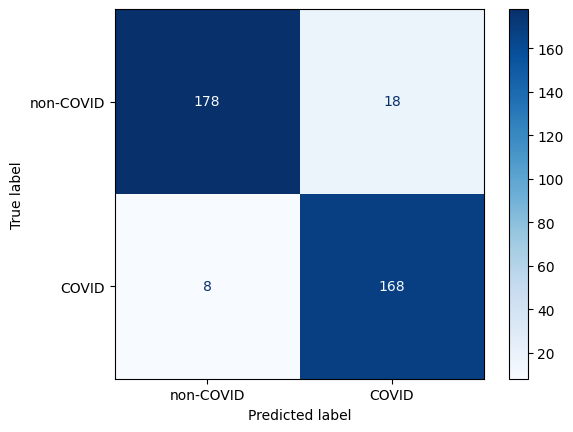

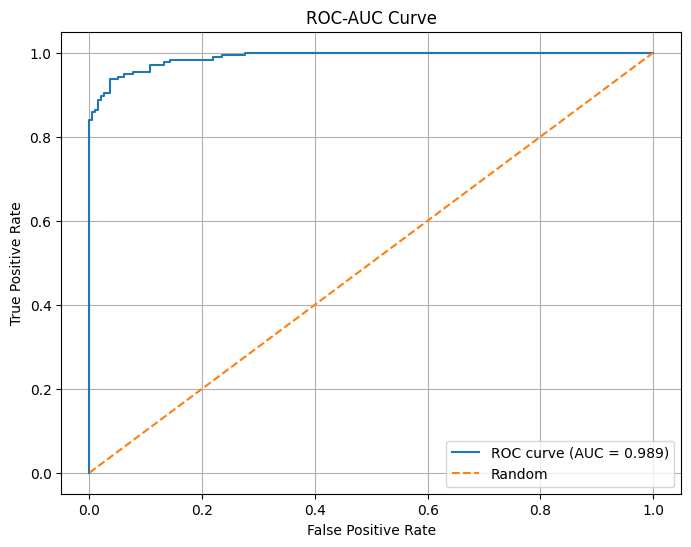

In [7]:
THRESHOLD = 0.3 # Порог для модели

calculate_metrics(model=baseline_model, dataloader=test_loader, threshold=THRESHOLD, device=device, class_to_idx=full_dataset.class_to_idx)